# Stage 2 — Standard (Additive) LoRA Fine-Tuning
## Model: `meta-llama/Llama-3.2-3B-Instruct` | Dataset: CB1 (6-Class Cyberbullying)

---

## Theory — Standard LoRA

**Standard LoRA — Wf = W + AB**

Standard LoRA adapts a pre-trained weight matrix W by adding a low-rank update:

> **Wf = W + AB**

where W ∈ ℝᵐˣⁿ is the frozen pre-trained weight, A ∈ ℝᵐˣʳ and B ∈ ℝʳˣⁿ are the trainable adapter matrices, and r ≪ min(m, n) is the rank — a small number that controls how many parameters are trained. Only A and B are updated during fine-tuning; W remains completely frozen. The low-rank constraint makes this parameter-efficient: instead of updating all m×n weights, only 2×r×n parameters are trained. At initialisation, B is set to zero so the adapter contributes nothing and training starts from the pre-trained behaviour. This is the additive-only baseline in the generalised framework — it corresponds to setting L₁ = I (no multiplicative component).

---

### Bugs Fixed in This Version
| # | Bug | Fix Applied |
|---|-----|-------------|
| 1 | `calculate_effective_rank()` computed rank of ΔW (trivially = r) instead of full Wf | Corrected to compute rank of **Wf = W + ΔW** |
| 2 | Label mapping used wrong class names (`gender/sexual`, `ethnicity/race`) | Updated to match dataset: `gender`, `ethnicity` + all 6 classes |
| 3 | `lora_alpha=8` with `lora_rank=16` → scaling=0.5 (non-standard) | Set `lora_alpha = lora_rank` throughout |
| 4 | `EarlyStoppingCallback` imported but never added to trainer | Removed — meaningless with 1 epoch |

### Research-Level Issues Fixed
| # | Issue | Fix Applied |
|---|-------|-------------|
| R1 | Efficiency story requires rank dynamics | Added rank dynamics + efficiency curve (rank sweep r∈{4,8,16,32}) |
| R2 | Downsampling applied to already-balanced data | **Removed** — CB1 (6-class) has 1.02× imbalance ratio |
| R3 | MCC missing from evaluation | Added `matthews_corrcoef` to all metric reports |
| R4 | 75/10/15 split deviated from 75/25 protocol | **Fixed** — 75% train / 25% test; val carved from within train |
| R5 | Panels 3 & 4 (grad norm / per-epoch loss) meaningless at 1 epoch | **Removed** — stability plot restructured to 2-panel |

---
**GPU Required**: A100 (40GB) recommended for Llama-3.2-3B-Instruct with 4-bit quantisation.

---
## Step 1: Install Required Libraries

**Purpose**: Install all Python packages needed for this notebook.

**What each package does**:
- `transformers` — loads Llama-3.2-3B-Instruct model and tokenizer
- `accelerate` — enables multi-GPU and mixed-precision training
- `bitsandbytes` — provides 4-bit quantisation (QLoRA) to fit large models on GPU
- `peft` — implements LoRA via the PEFT library
- `datasets` — converts pandas DataFrames to HuggingFace Dataset objects
- `scikit-learn` — provides all evaluation metrics (F1, MCC, etc.)
- `matplotlib` / `seaborn` — confusion matrix and training curve visualisations

In [1]:
# ── Install all required libraries ──────────────────────────────────────────
!pip install -q -U \
    "transformers>=4.43.0" \
    "accelerate>=0.33.0" \
    "bitsandbytes>=0.43.0" \
    "peft>=0.11.1" \
    datasets \
    scikit-learn \
    matplotlib \
    seaborn

print("✓ All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 142.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 150.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 50.3 MB/s eta 0:00:00
✓ All libraries installed successfully.


---
## Step 2: Import Libraries and Initial Setup

**Purpose**: Import all modules, set random seeds for reproducibility, load the HuggingFace token, and mount Google Drive.

**Key design decisions**:
- `set_all_seeds(42)` ensures deterministic behaviour across PyTorch, NumPy, and Python random.
- The HuggingFace token (`HF_TOKEN`) is loaded from Colab Secrets — never hardcoded.
- No `EarlyStoppingCallback` is imported: with 1 epoch it is meaningless and was removed (Fix Bug 4).

In [2]:
import os
import random
import collections
import re
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
)

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from peft.tuners.lora import LoraLayer
from google.colab import drive, userdata

# ── Reproducibility ─────────────────────────────────────────────────────────
def set_all_seeds(seed: int = 42):
    """Fix all random seeds for fully reproducible training."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

# ── HuggingFace token ────────────────────────────────────────────────────────
def load_hf_token() -> str:
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add it via Colab Secrets (key icon in sidebar).")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()

# ── Mount Google Drive ───────────────────────────────────────────────────────
drive.mount('/content/drive')
print("✓ Google Drive mounted.")

# ── GPU check ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Purpose**: Define all hyperparameters and settings in one place.

**Key design decisions**:
- `LORA_ALPHA = LORA_RANK` — standard convention; scaling = alpha/rank = 1.0.
- `RANK_SWEEP = [4, 8, 16, 32]` — ablation across four ranks for the efficiency curve.
- `NUM_EPOCHS = 1` — single epoch as specified by the research protocol.
- **Split protocol**: 75% train+val / 25% test (stratified, seed=42). A validation set
  of `VAL_FROM_TRAIN = 0.10` (10% of the 75% train portion) is carved for the Trainer's
  `eval_dataset`. The held-out test set is always the full 25% — never touched during training.

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

# ── Model ────────────────────────────────────────────────────────────────────
MODEL_NAME   = "meta-llama/Llama-3.2-3B-Instruct"
NUM_LABELS   = 6
MAX_LENGTH   = 256

# ── LoRA ─────────────────────────────────────────────────────────────────────
LORA_RANK    = 16
LORA_ALPHA   = 16           # always equals LORA_RANK → scaling = 1.0
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 16, 32]

# ── Training ─────────────────────────────────────────────────────────────────
NUM_EPOCHS          = 1     # single epoch — protocol requirement
LEARNING_RATE       = 2e-4
TRAIN_BATCH_SIZE    = 16
EVAL_BATCH_SIZE     = 32
WEIGHT_DECAY        = 0.01
EVAL_STEPS          = 200
LOGGING_STEPS       = 50
OUTPUT_DIR          = "/content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B"

# ── Dataset & Split ───────────────────────────────────────────────────────────
# Protocol: 75/25 stratified split (seed=42), TF-IDF near-duplicate removal @0.90
# Val set is carved from within the 75% train portion for the Trainer's eval_dataset.
# The 25% test set is held out completely and never seen during training.
CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75      # 75% → split into train_actual + val
TEST_RATIO           = 0.25      # 25% → held-out test set (protocol)
VAL_FROM_TRAIN       = 0.10      # 10% of the 75% train portion → val for Trainer
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# ── Label mapping ─────────────────────────────────────────────────────────────
LABEL_MAPPING = {
    'not_cyberbullying':   0,
    'gender':              1,
    'religion':            2,
    'ethnicity':           3,
    'age':                 4,
    'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Model      : {MODEL_NAME}")
print(f"  LoRA rank  : {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  Split      : {int(TRAIN_RATIO*100)}% train+val / {int(TEST_RATIO*100)}% test  (protocol: 75/25)")
print(f"  Val carved : {int(VAL_FROM_TRAIN*100)}% of train → Trainer eval_dataset")
print(f"  Labels ({NUM_LABELS}) : {TARGET_NAMES}")

✓ Configuration loaded.
  Model      : meta-llama/Llama-3.2-3B-Instruct
  LoRA rank  : 16  |  alpha: 16  |  scaling: 1.0
  Epochs     : 1
  Split      : 75% train+val / 25% test  (protocol: 75/25)
  Val carved : 10% of train → Trainer eval_dataset
  Labels (6) : ['not_cyberbullying', 'gender', 'religion', 'ethnicity', 'age', 'other_cyberbullying']


---
## Step 4: Text Preprocessing

**Purpose**: Define an LLM-optimised preprocessing function for raw tweet text.

**Why this approach for LLMs**: Preserves natural language structure while removing noise.
- Replaces URLs with `[URL]` and @mentions with `[USER]`
- Removes RT prefixes
- Keeps emojis and hashtags (carry semantic information for cyberbullying detection)
- Discards texts shorter than 3 words

In [4]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    """LLM-optimised tweet preprocessing."""
    if not isinstance(text, str):
        return ""

    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags:
        text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis:
        text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3:
        return ""
    return text

# ── Quick sanity check ───────────────────────────────────────────────────────
test_tweet = "RT @user123: Check this out http://example.com !!! @someone is so dumb"
print("Before:", test_tweet)
print("After: ", preprocess_text_for_llm(test_tweet))
print("\n✓ Preprocessing function defined.")

Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

**Purpose**: Load `cyberbullying_tweets.csv`, apply all data cleaning steps.

**Cleaning steps**:
1. Rename columns → `text`, `label`
2. Remove corrupt rows (`#NAME?` Excel errors)
3. Apply LLM preprocessing
4. Remove cross-label annotation conflicts (same tweet, different labels)
5. Remove exact duplicates
6. Remove very short texts (< 3 words)

**No downsampling** (Fix R2): CB1 imbalance ratio is 1.02× — downsampling discards valid data.

In [5]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")

df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
print(f"[2] Columns renamed: {df.columns.tolist()}")

corrupt_mask = df['text'].astype(str).str.strip().isin(
    ['#NAME?', '#REF!', '#VALUE!', '#N/A', 'nan', ''])
n_corrupt = corrupt_mask.sum()
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {n_corrupt} corrupt rows → {len(df):,} remaining")

df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")

text_label_counts = df.groupby('text')['label'].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
n_conflicting     = df['text'].isin(conflicting_texts).sum()
df = df[~df['text'].isin(conflicting_texts)].reset_index(drop=True)
print(f"[5] Removed {n_conflicting:,} annotation-conflict rows → {len(df):,} remaining")

before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")

before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before - len(df):,} short texts → {len(df):,} remaining")

unknown_labels = set(df['label'].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown_labels) == 0, f"Unknown labels: {unknown_labels}"

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
imbalance = counts.max() / counts.min()
print(f"\n  Imbalance ratio : {imbalance:.2f}×  → no downsampling needed")
print("  Primary metric  : Macro F1  |  Secondary: MCC")

════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[2] Columns renamed: ['text', 'label']
[3] Removed 0 corrupt rows → 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed 3,250 annotation-conflict rows → 43,692 remaining
[6] Removed 358 exact duplicates → 43,334 remaining
[7] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio : 1.37×  → no downsampling needed
  Primary metric 

---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

**Purpose**: Split the cleaned dataset into train (75%) and test (25%) following the research
protocol, carve a validation set from within the train portion, then check for near-duplicate
leakage between train and test using TF-IDF cosine similarity.

**Split structure** (protocol-compliant):
```
Full dataset (100%)
├── Train+Val : 75%
│   ├── Val   : 10% of 75% = 7.5% of total  → Trainer eval_dataset
│   └── Train : 90% of 75% = 67.5% of total → actual training data
└── Test      : 25% of total                 → held-out, never seen during training
```

**Near-duplicate removal**: Any test sample with cosine similarity ≥ 0.90 to a training sample
(TF-IDF, bigrams) is moved to train to prevent leakage. Performed between train (full 75%) and
test (25%) before carving val, so val is always leak-free by construction.

In [6]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

# ── Step 6a: Primary stratified split — 75% train+val, 25% test ──────────────
train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_RATIO,          # 25% test (protocol)
    random_state=RANDOM_STATE,
    stratify=df['label']
)
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
print(f"    ({len(train_val_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%)")

# ── Step 6b: Near-duplicate leakage check (TF-IDF cosine) ───────────────────
print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")

all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
batch_size     = 500
for start in range(0, len(test_df), batch_size):
    end         = min(start + batch_size, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    max_sims    = batch_sims.max(axis=1)
    leaked_mask = max_sims >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")

if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df      = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train+val → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

# ── Step 6c: Data leakage assertion ──────────────────────────────────────────
train_val_texts = set(train_val_df['text'].tolist())
test_texts      = set(test_df['text'].tolist())
overlap         = train_val_texts.intersection(test_texts)
assert len(overlap) == 0, f"DATA LEAKAGE DETECTED: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed — zero train/test overlap.")

# ── Step 6d: Carve validation set from within the 75% train portion ──────────
# Val is 10% of the 75% → used as eval_dataset for Trainer only.
# Test remains the full 25% held-out set.
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_FROM_TRAIN,      # 10% of train portion
    random_state=RANDOM_STATE,
    stratify=train_val_df['label']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"\n[3] Validation carved from train → Train: {len(train_df):,} | Val: {len(val_df):,}")

# ── Step 6e: Final split statistics ──────────────────────────────────────────
print("\n" + "═" * 60)
print("FINAL SPLIT STATISTICS")
print("═" * 60)
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct = len(split_df) / len(df) * 100
    print(f"\n{name} ({len(split_df):,} samples, {pct:.1f}% of total):")
    for label, count in split_df['label'].value_counts().sort_index().items():
        print(f"  {label:<25} {count:>5}  ({count/len(split_df)*100:.1f}%)")

print(f"\n  ✓ Protocol check: test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")

════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834
    (75.0% / 25.0%)

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved to train+val → Train+Val: 33,004 | Test: 10,330

    ✓ Data leakage assertion passed — zero train/test overlap.

[3] Validation carved from train → Train: 29,703 | Val: 3,301

════════════════════════════════════════════════════════════
FINAL SPLIT STATISTICS
════════════════════════════════════════════════════════════

Train (29,703 samples, 68.5% of total):
  age                        5420  (18.2%)
  ethnicity                  5497  (18.5%)
  gender                     5149  (17.3%)
  not_cyberbullying          4235  (14.3%)
  other_cyberbullying        3995  (13.4%)
  religion                   5407  (18.2%)

Validation (3,301 samples, 7.6% of

---
## Step 7: Helper Functions — Class Weights

**Purpose**: Compute inverse-frequency class weights for the loss function.

**Formula**: weight_c = N / (C × n_c), normalised to sum=1.

Even though CB1 has 1.02× imbalance, class weights are included as a robustness measure
and keep the code consistent with the CB2 notebook (where 8.6:1 imbalance makes them essential).

In [7]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    """Compute inverse-frequency class weights sorted by label integer index."""
    if df.empty:
        return None
    df_mapped = df.copy()
    if df_mapped[label_col].dtype == object:
        df_mapped[label_col] = df_mapped[label_col].map(LABEL_MAPPING)
    class_counts = df_mapped[label_col].value_counts().sort_index()
    N = class_counts.sum()
    C = len(class_counts)
    weights = N / (C * class_counts.values)
    weights = weights / weights.sum()
    return weights.tolist()

train_class_weights = get_class_weights(train_df)
print("Class weights (inverse frequency, normalised):")
for label_name, w in zip(TARGET_NAMES, train_class_weights):
    print(f"  {label_name:<25}  weight = {w:.4f}")
print("\n✓ Class weights computed. Near-equal due to 1.02× balance ratio.")

Class weights (inverse frequency, normalised):
  not_cyberbullying          weight = 0.1917
  gender                     weight = 0.1576
  religion                   weight = 0.1501
  ethnicity                  weight = 0.1477
  age                        weight = 0.1498
  other_cyberbullying        weight = 0.2032

✓ Class weights computed. Near-equal due to 1.02× balance ratio.


---
## Step 8: Effective Rank Computation — CORRECTED (4-bit QLoRA Compatible)

**Purpose**: Compute the effective rank of the adapted weight matrix **Wf = W + ΔW**.

**Fix Bug 1**: The original code computed SVD of ΔW = B@A only — always trivially equal to r.
We now compute SVD of the full **Wf = W + ΔW**.

**4-bit QLoRA fix**: Uses `bitsandbytes.functional.dequantize_4bit()` to correctly reconstruct
W from its NF4 quantised representation. Calling `.float()` directly on a 4-bit weight returns
garbage values, causing `avg_effective_rank(Wf) = 0.00`.

**Definition**: eff_rank(Wf) = |{σᵢ : σᵢ > τ · σ₁(Wf)}| where τ = 1e-3 (default).

In [8]:
def calculate_effective_rank(model: nn.Module,
                              threshold_ratio: float = 1e-3) -> Dict[str, float]:
    """
    Compute effective rank of the FULL adapted weight Wf = W + ΔW.

    FIX Bug1  : SVD on Wf = W + ΔW, not ΔW alone.
    FIX 4-bit : Uses bnb_F.dequantize_4bit() to reconstruct W from NF4 storage.

    Returns
    -------
    dict: avg_effective_rank_Wf, avg_effective_rank_deltaW,
          lora_layer_count, per_layer_ranks
    """
    try:
        import bitsandbytes.functional as bnb_F
        BNB_AVAILABLE = True
    except ImportError:
        BNB_AVAILABLE = False
        print("  ⚠ bitsandbytes not found — 4-bit dequantisation unavailable.")

    full_ranks  = []
    delta_ranks = []
    per_layer   = []
    skipped     = 0

    for name, module in model.named_modules():
        if not isinstance(module, LoraLayer):
            continue
        try:
            A       = module.lora_A.default.weight.data
            B       = module.lora_B.default.weight.data
            scaling = module.scaling
            if isinstance(scaling, dict):
                scaling = scaling.get('default', 1.0)

            delta_W = (B @ A * scaling).float()

            S_delta = torch.linalg.svdvals(delta_W)
            r_delta = int((S_delta > threshold_ratio * S_delta[0]).sum()) if S_delta[0] > 0 else 0
            delta_ranks.append(r_delta)

            base_layer = module.base_layer
            if not hasattr(base_layer, 'weight'):
                skipped += 1
                continue

            weight_obj = base_layer.weight

            if hasattr(weight_obj, 'quant_state') and BNB_AVAILABLE:
                try:
                    W = bnb_F.dequantize_4bit(
                        weight_obj.data, weight_obj.quant_state
                    ).float()
                except Exception:
                    skipped += 1
                    continue
            else:
                W = weight_obj.data.float()

            if W.shape != delta_W.shape:
                if W.T.shape == delta_W.shape:
                    W = W.T.contiguous()
                else:
                    skipped += 1
                    continue

            Wf   = W + delta_W
            S_Wf = torch.linalg.svdvals(Wf)
            r_full = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0

            full_ranks.append(r_full)
            per_layer.append({'layer': name, 'rank_Wf': r_full, 'rank_deltaW': r_delta})

        except Exception:
            skipped += 1
            continue

    if skipped > 0:
        print(f"  ℹ {skipped} LoRA layers skipped (shape mismatch or quantisation issue)")

    return {
        "avg_effective_rank_Wf":     float(np.mean(full_ranks))  if full_ranks  else 0.0,
        "avg_effective_rank_deltaW": float(np.mean(delta_ranks)) if delta_ranks else 0.0,
        "lora_layer_count":          len(full_ranks),
        "per_layer_ranks":           per_layer,
    }

print("✓ calculate_effective_rank() — 4-bit QLoRA compatible.")
print("  → SVD on Wf = W + ΔW  (theoretically meaningful)")
print("  → ΔW rank tracked as reference  (trivially ≤ r)")

✓ calculate_effective_rank() — 4-bit QLoRA compatible.
  → SVD on Wf = W + ΔW  (theoretically meaningful)
  → ΔW rank tracked as reference  (trivially ≤ r)


---
## Step 9: Evaluation Metrics

**Purpose**: Define all metric functions used during training and final evaluation.

**Fix R3 — MCC added**: `matthews_corrcoef` is now included in all metric reports.
MCC captures all four quadrants of the confusion matrix and is robust to class imbalance.

In [9]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    """Called by the Trainer at every eval_steps. Returns metrics for checkpointing."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true: List[int],
                     y_pred: List[int],
                     dataset_name: str) -> Dict[str, float]:
    """Full evaluation report: per-class F1, MCC, confusion matrices."""
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)

    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")

    print(f"\n  Classification Report:")
    report = classification_report(
        y_true, y_pred,
        labels=list(range(NUM_LABELS)),
        target_names=TARGET_NAMES,
        zero_division=0, digits=4
    )
    print(report)

    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}', fontsize=12)
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised — Recall)\n{dataset_name}', fontsize=12)
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'accuracy': accuracy, 'macro_f1': macro_f1,
        'weighted_f1': weighted_f1, 'balanced_accuracy': bal_accuracy, 'mcc': mcc,
    }


def make_predictions(model, df_test, tokenizer, batch_size=32):
    """Run batched inference. Returns df_test with a 'predictions' column added."""
    model.eval()
    sentences  = df_test['text'].tolist()
    all_logits = []
    dev        = next(model.parameters()).device
    with torch.no_grad():
        for start in range(0, len(sentences), batch_size):
            batch  = sentences[start:start + batch_size]
            inputs = tokenizer(batch, return_tensors="pt",
                               padding=True, truncation=True, max_length=MAX_LENGTH)
            inputs  = {k: v.to(dev) for k, v in inputs.items()}
            outputs = model(**inputs)
            all_logits.append(outputs.logits.cpu())
    all_logits         = torch.cat(all_logits, dim=0)
    df_test            = df_test.copy()
    df_test['predictions'] = all_logits.argmax(dim=1).numpy()
    return df_test

print("✓ Metric functions defined.")
print("  → compute_metrics    : accuracy, macro F1, MCC (Trainer)")
print("  → evaluate_dataset   : full report + dual confusion matrix")
print("  → make_predictions   : batched inference with model.eval() guard")

✓ Metric functions defined.
  → compute_metrics    : accuracy, macro F1, MCC (Trainer)
  → evaluate_dataset   : full report + dual confusion matrix
  → make_predictions   : batched inference with model.eval() guard


---
## Step 10: Training Stability System

**Purpose**: Define the stability measurement system and the custom weighted-loss Trainer.

### Two Stability Dimensions Measured (Single-Epoch Protocol)

| Dimension | Metric | What It Reveals |
|---|---|---|
| **Loss Stability** | Std dev & CV of training loss across steps | Spiky/erratic loss = unstable optimisation |
| **Metric Stability** | Std dev of val F1 & MCC across eval checkpoints | Large swings = model hasn't converged within the epoch |

> **Why only 2 dimensions?** With a single training epoch, "Gradient Norm Per Epoch" and
> "Per-Epoch Loss Stability" produce trivially uninformative single-point charts and have
> been removed per the research protocol. The stability plot is restructured to 2 panels.

### Composite Stability Score (Loss CV + Val F1 Std)
- `< 0.05` — very stable
- `0.05 – 0.15` — acceptable
- `> 0.15` — investigate before publishing

In [10]:
import matplotlib.gridspec as gridspec
from typing import Optional

class StabilityCallback(TrainerCallback):
    """
    2-dimension stability tracking (single-epoch protocol).

    Dimension 1 — Loss stability   : std dev & CV of training loss across steps
    Dimension 2 — Metric stability : std dev of val F1 & MCC across eval checkpoints

    Gradient norm per epoch and per-epoch loss stability panels are intentionally
    omitted — they are uninformative with a single training epoch.
    """

    def __init__(self):
        self.train_losses = []          # (step, loss)
        self.val_metrics  = collections.defaultdict(list)
        self.val_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0:
            return
        if 'loss' in logs:
            self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            clean = key.replace('eval_', '')
            self.val_metrics[clean].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}

        # ── 1. Loss stability ─────────────────────────────────────────────────
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr) / np.mean(arr)) if np.mean(arr) > 0 else 0.0

        # ── 2. Validation metric stability ────────────────────────────────────
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max() - arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])

        # ── 3. Composite stability score (2-dimension, single-epoch) ──────────
        # Loss CV (50%) + Val F1 Std (50%) — grad norm removed (1 epoch)
        loss_cv = report.get('loss_cv_overall', 0.0)
        f1_std  = report.get('val_f1_std', 0.0)
        report['stability_score'] = round((loss_cv * 0.5) + (f1_std * 0.5), 6)

        return report

    def plot_stability_curves(self, stage_label: str = 'Stage 2', save_path: str = None):
        """
        2-panel stability figure (single-epoch protocol).

        Panel 1 — Training loss curve with rolling mean
        Panel 2 — Validation F1 and MCC across eval checkpoints

        Panels 3 & 4 (Gradient Norm Per Epoch / Per-Epoch Loss Stability) are
        intentionally omitted — uninformative with a single training epoch.
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # ── Panel 1: Training loss curve ──────────────────────────────────────
        if self.train_losses:
            steps  = [s for (s, _) in self.train_losses]
            losses = [l for (_, l) in self.train_losses]

            ax1.plot(steps, losses, color='steelblue', linewidth=0.7,
                     alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy',
                         linewidth=2.2, label=f'Rolling mean (w={window})')

            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)
            ax1.set_xlabel('Global Step')
            ax1.set_ylabel('Cross-Entropy Loss')
            ax1.legend(fontsize=9)
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No training loss data collected.',
                     ha='center', va='center', transform=ax1.transAxes, fontsize=10, color='grey')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)

        # ── Panel 2: Validation F1 and MCC ───────────────────────────────────
        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None

            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen',
                         linewidth=2, markersize=5, label='Macro F1')
                f1_mean = float(np.mean(f1_vals))
                f1_std  = float(np.std(f1_vals))
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':',
                             linewidth=1.2, alpha=0.6)
                ax2.fill_between(self.val_steps,
                                  [f1_mean - f1_std]*len(self.val_steps),
                                  [f1_mean + f1_std]*len(self.val_steps),
                                  color='forestgreen', alpha=0.10,
                                  label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen', fontsize=10)
                ax2.tick_params(axis='y', labelcolor='forestgreen')

            if ax2_r is not None and 'mcc' in self.val_metrics:
                ax2_r.plot(self.val_steps, self.val_metrics['mcc'],
                           's--', color='darkorange', linewidth=2,
                           markersize=5, label='MCC')
                ax2_r.set_ylabel('MCC', color='darkorange', fontsize=10)
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
                lines1, lbl1 = ax2.get_legend_handles_labels()
                lines2, lbl2 = ax2_r.get_legend_handles_labels()
                ax2.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='lower right')

            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)
            ax2.set_xlabel('Global Step')
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No validation metric data collected.',
                     ha='center', va='center', transform=ax2.transAxes, fontsize=10, color='grey')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)

        plt.suptitle(f'Training Stability Analysis — {stage_label}',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'  ✓ Stability plot saved → {save_path}')
        plt.show()


class CustomTrainer(Trainer):
    """Extends HuggingFace Trainer with class-weighted cross-entropy loss."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
            if class_weights is not None else None
        )

    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels  = inputs.pop('labels').long()
        outputs = model(**inputs)
        loss    = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss


def plot_cross_stage_stability(stage_reports: Dict[str, Dict], save_path: str = None):
    """
    Side-by-side comparison of stability metrics across Stages 2, 3, 4.
    Call AFTER all three stage notebooks have completed.

    Parameters
    ----------
    stage_reports : {stage_label: stability_report_dict}
        e.g. {
            'Stage 2\nWf=W+AB':        report_s2,
            'Stage 3\nWf=W(I+UV)':     report_s3,
            'Stage 4\nWf=W(I+UV)+AB':  report_s4,
        }
    """
    labels  = list(stage_reports.keys())
    n       = len(labels)
    colours = ['#2E75B6', '#2E86AB', '#1B998B', '#F4A261'][:n]

    metrics_map = {
        'Loss Std Dev\n(Overall)':              'loss_std_overall',
        'Loss CV\n(Coeff. of Variation)':       'loss_cv_overall',
        'Val F1 Std Dev\n(Across Checkpoints)': 'val_f1_std',
        'Composite\nStability Score':           'stability_score',
    }

    fig, axes = plt.subplots(1, len(metrics_map), figsize=(5.5 * len(metrics_map), 6))
    for ax, (metric_label, metric_key) in zip(axes, metrics_map.items()):
        values = [stage_reports[lbl].get(metric_key, 0.0) or 0.0 for lbl in labels]
        bars   = ax.bar(range(n), values, color=colours, alpha=0.85,
                        edgecolor='white', linewidth=1.5, width=0.6)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(values + [1e-9]) * 0.03,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(n))
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(metric_label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value  (lower = more stable)', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        if metric_key == 'stability_score':
            ax.axhspan(0,    0.05,  alpha=0.08, color='green',  label='Very stable')
            ax.axhspan(0.05, 0.15,  alpha=0.08, color='orange', label='Acceptable')
            ax.axhspan(0.15, max(values + [0.2]) * 1.2, alpha=0.08, color='red', label='Unstable')
            ax.legend(fontsize=8, loc='upper left')

    plt.suptitle(
        'Cross-Stage Training Stability Comparison\n'
        'CB1 — 6-Class Cyberbullying | meta-llama/Llama-3.2-3B-Instruct',
        fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  ✓ Cross-stage stability plot saved → {save_path}')
    plt.show()

print('✓ StabilityCallback (2-dimension, single-epoch protocol) defined.')
print('  Dimension 1 — Loss stability  : std dev & CV across steps')
print('  Dimension 2 — Metric stability: val F1 & MCC std across checkpoints')
print('  [Panels 3 & 4 removed — uninformative with 1 epoch]')
print()
print('✓ CustomTrainer defined (class-weighted cross-entropy loss).')
print('✓ plot_cross_stage_stability() defined — call after all stages complete.')

✓ StabilityCallback (2-dimension, single-epoch protocol) defined.
  Dimension 1 — Loss stability  : std dev & CV across steps
  Dimension 2 — Metric stability: val F1 & MCC std across checkpoints
  [Panels 3 & 4 removed — uninformative with 1 epoch]

✓ CustomTrainer defined (class-weighted cross-entropy loss).
✓ plot_cross_stage_stability() defined — call after all stages complete.


---
## Step 11: Standard LoRA Training Function

**Purpose**: Define `run_standard_lora()` — a complete training + evaluation run for a given LoRA rank `r`.

**Formulation**: `Wf = W + AB`,  A ∈ ℝᵐˣʳ, B ∈ ℝʳˣⁿ, B initialised to 0

**All fixes applied in this function**:
- **Bug 1**: `calculate_effective_rank()` computes rank of Wf = W + ΔW
- **Bug 2**: Label mapping uses correct 6-class names (`gender`, `ethnicity`)
- **Bug 3**: `lora_alpha = lora_rank` (scaling = 1.0) — enforced inside function
- **Bug 4**: `EarlyStoppingCallback` removed — meaningless with 1 epoch; `load_best_model_at_end=False`
- **Fix R4**: 75/25 split — test_df is always the held-out 25% set
- **Fix R5**: Stability plot is 2-panel (no grad norm / per-epoch loss panels)

In [11]:
def run_standard_lora(
    train_df:  pd.DataFrame,
    val_df:    pd.DataFrame,
    test_df:   pd.DataFrame,
    lora_rank: int,
    run_label: str = ''
) -> Dict:
    """
    Train and evaluate Standard (Additive) LoRA on CB1.

    Stage 2 formulation:  Wf = W + AB

    Parameters
    ----------
    train_df  : training DataFrame  (text, label as string)
    val_df    : validation DataFrame (text, label as string)
    test_df   : held-out test DataFrame — 25% of full dataset (protocol)
    lora_rank : LoRA rank r; lora_alpha is set equal to r inside this function
    run_label : identifier string for file naming and logging

    Returns
    -------
    dict with all metrics, rank analysis, stability report, and callback object
    """
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank     # scaling = alpha/rank = 1.0 always
    label      = run_label or f'StandardLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 2 — STANDARD LoRA  |  {label}')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Rank r  : {lora_rank}  |  Alpha: {lora_alpha}  |  Scaling: {lora_alpha/lora_rank:.1f}')
    print(f'  Formula : Wf = W + AB')
    print(f'  Epochs  : {NUM_EPOCHS}  (single-epoch protocol)')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # ── 1. Tokenizer ──────────────────────────────────────────────────────────
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME, token=HF_TOKEN, add_prefix_space=True)
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab size: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'],
                         padding='max_length', truncation=True, max_length=MAX_LENGTH)

    # ── 2. Label mapping and dataset preparation ──────────────────────────────
    print('[2] Mapping labels and preparing datasets...')
    train_m = train_df.copy()
    val_m   = val_df.copy()
    test_m  = test_df.copy()

    for split in [train_m, val_m, test_m]:
        split['label'] = split['label'].map(LABEL_MAPPING)
        assert split['label'].notnull().all(), 'Unmapped labels detected!'

    hf_train = Dataset.from_pandas(
        train_m[['text', 'label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(
        val_m[['text', 'label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch')
    hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    # ── 3. Quantisation config (4-bit NF4 QLoRA) ─────────────────────────────
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    # ── 4. LoRA config ────────────────────────────────────────────────────────
    lora_config = LoraConfig(
        r=lora_rank,
        lora_alpha=lora_alpha,     # scaling = 1.0
        target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT,
        bias='none',
        task_type='SEQ_CLS',
    )

    # ── 5. Load model ─────────────────────────────────────────────────────────
    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        num_labels=NUM_LABELS,
        dtype=torch.bfloat16,
        device_map='auto',
        token=HF_TOKEN,
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache    = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    trainable, total = model.get_nb_trainable_parameters()
    print(f'   Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)')

    # ── 6. Training arguments ─────────────────────────────────────────────────
    # load_best_model_at_end=False: meaningless with 1 epoch (no best to select)
    training_args = TrainingArguments(
        output_dir=run_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='steps',
        eval_steps=EVAL_STEPS,
        logging_strategy='steps',
        logging_steps=LOGGING_STEPS,
        save_strategy='no',
        load_best_model_at_end=False,  # meaningless with 1 epoch — removed
        warmup_ratio=0.05,
        lr_scheduler_type='cosine',
        fp16=False,
        bf16=True,
        report_to='none',
        dataloader_pin_memory=False,
    )

    # ── 7. Trainer (no EarlyStoppingCallback with 1 epoch) ───────────────────
    stability_cb = StabilityCallback()

    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=hf_train,
        eval_dataset=hf_val,
        compute_metrics=compute_metrics,
        class_weights=get_class_weights(train_m),
        callbacks=[stability_cb],
    )

    # ── 8. Train ──────────────────────────────────────────────────────────────
    print(f'[4] Training — {NUM_EPOCHS} epoch (single-epoch protocol)...')
    trainer.train()

    # ── 9. Effective rank ─────────────────────────────────────────────────────
    print('\n[5] Computing effective rank of Wf = W + AB...')
    rank_metrics = calculate_effective_rank(model)
    print(f'   avg_effective_rank(Wf) = {rank_metrics["avg_effective_rank_Wf"]:.2f}')
    print(f'   avg_effective_rank(ΔW) = {rank_metrics["avg_effective_rank_deltaW"]:.2f}  (reference, ≤ r={lora_rank})')
    print(f'   LoRA layers measured   = {rank_metrics["lora_layer_count"]}')

    # ── 10. Stability report ──────────────────────────────────────────────────
    print('\n[6] Generating stability report...')
    stability_report = stability_cb.get_stability_report()
    print(f'   Loss CV (overall)   : {stability_report.get("loss_cv_overall",  "N/A")}')
    print(f'   Loss std (overall)  : {stability_report.get("loss_std_overall", "N/A")}')
    print(f'   Val F1 std          : {stability_report.get("val_f1_std",       "N/A")}')
    print(f'   Val MCC std         : {stability_report.get("val_mcc_std",      "N/A")}')
    print(f'   Composite score     : {stability_report.get("stability_score",  "N/A")}')
    score = stability_report.get('stability_score', None)
    if score is not None:
        if score < 0.05:
            print('   Interpretation      : ✅  Very stable (score < 0.05)')
        elif score < 0.15:
            print('   Interpretation      : 🟡  Acceptable (0.05 ≤ score < 0.15)')
        else:
            print('   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 2 — Standard LoRA  (Wf = W + AB, r={lora_rank})',
        save_path=os.path.join(run_dir, 'stability_curves.png')
    )

    # ── 11. Inference on held-out 25% test set ────────────────────────────────
    print('[7] Running inference on held-out test set (25% of full dataset)...')
    test_with_preds = make_predictions(model, test_m, tokenizer)
    final_metrics = evaluate_dataset(
        y_true=test_with_preds['label'].tolist(),
        y_pred=test_with_preds['predictions'].tolist(),
        dataset_name=f'CB1 Test — {label}'
    )

    # ── 12. Compile results ───────────────────────────────────────────────────
    results = {
        'run_label':        label,
        'lora_rank':        lora_rank,
        'lora_alpha':       lora_alpha,
        'trainable_params': trainable,
        **final_metrics,
        'avg_eff_rank_Wf':  rank_metrics['avg_effective_rank_Wf'],
        'avg_eff_rank_dW':  rank_metrics['avg_effective_rank_deltaW'],
        'stability_score':  stability_report.get('stability_score', None),
        'stability_report': stability_report,
        'stability_cb':     stability_cb,
    }

    scalars_path = os.path.join(run_dir, f'results_{label}.csv')
    pd.DataFrame([{k: v for k, v in results.items()
                   if not isinstance(v, (dict, StabilityCallback))}
                 ]).to_csv(scalars_path, index=False)
    print(f'\n✓ Results saved → {scalars_path}')

    del model, trainer
    torch.cuda.empty_cache()
    return results

print('✓ run_standard_lora() fully defined.')

✓ run_standard_lora() fully defined.


---
## Step 12: Execute — Default Run (r = 16)

**Purpose**: Run Stage 2 Standard LoRA with the default rank r=16 on CB1.

**Output produced by this cell**:
1. Live training loss across steps with stability stats
2. `plot_stability_curves()` — 2-panel figure (loss curve + val metrics) saved to `OUTPUT_DIR`
3. Full evaluation on the held-out 25% test set (Macro F1, MCC, confusion matrices)
4. Summary table showing all key metrics

**Stability callback stored**: `results_r16['stability_cb']` — pass to `plot_cross_stage_stability()` after Stages 3 & 4 complete.

**Targets to beat** (from Stage 1 baselines):
- CB1 Macro F1 > 0.5757 (Phi-4 FS best)  |  MCC > 0.5614

✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r16
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

   Trainable: 9,193,472 / 3,221,961,728  (0.285%)
[4] Training — 1 epoch (single-epoch protocol)...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.509117,0.443890,0.847622,0.830707,0.818979
400,0.415798,0.451480,0.869736,0.848490,0.845233
600,0.380967,0.372116,0.878825,0.870053,0.855677
800,0.338911,0.350250,0.900636,0.889653,0.880750
1000,0.286124,0.366660,0.888216,0.872032,0.869209
1200,0.359507,0.289259,0.912754,0.903418,0.895091
1400,0.303935,0.280552,0.909724,0.900424,0.891629
1600,0.254335,0.276471,0.910330,0.901695,0.892307
1800,0.233726,0.273205,0.911239,0.902876,0.893423
1857,0.351219,0.272966,0.911239,0.902871,0.893418


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2030.73
   avg_effective_rank(ΔW) = 16.00  (reference, ≤ r=16)
   LoRA layers measured   = 112

[6] Generating stability report...
   Loss CV (overall)   : 0.8250890329112768
   Loss std (overall)  : 0.34319385762043336
   Val F1 std          : 0.024721563075468946
   Val MCC std         : 0.024702983008093447
   Composite score     : 0.424905
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r16/stability_curves.png


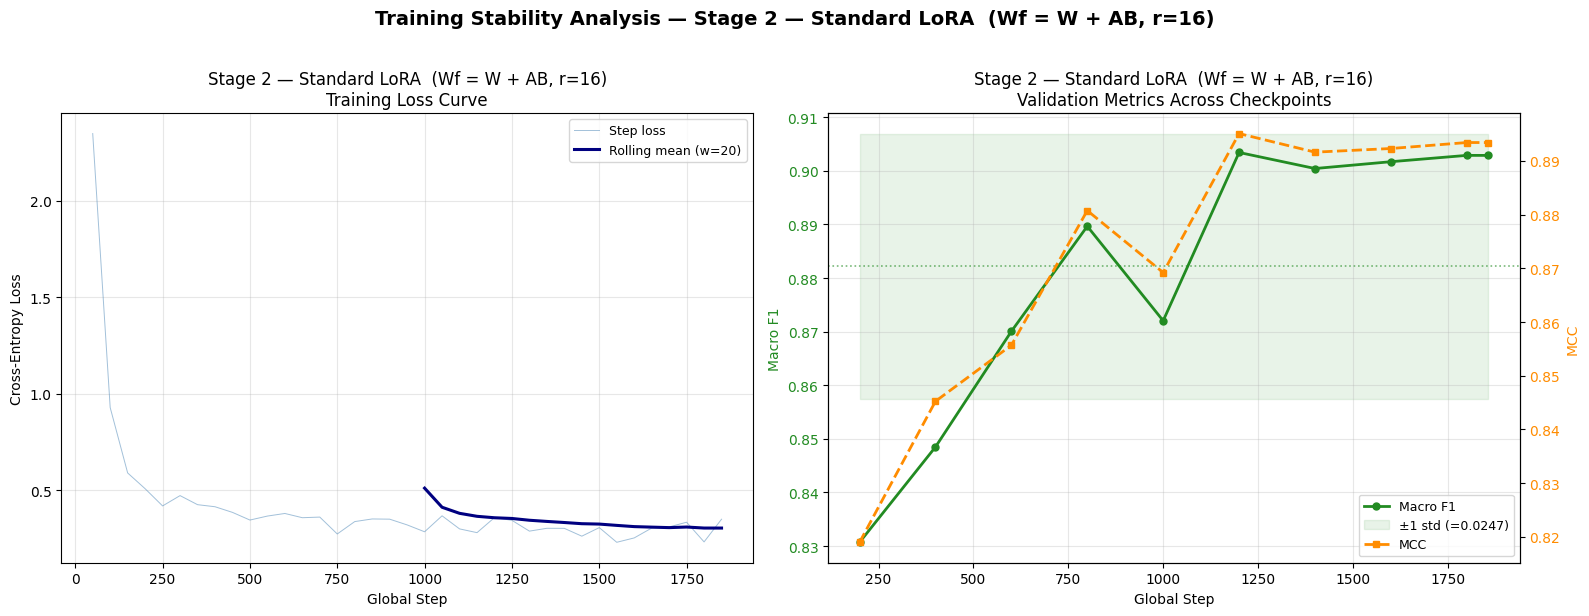

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9045
  Macro F1          : 0.8938  ← PRIMARY METRIC
  Weighted F1       : 0.9055
  Balanced Accuracy : 0.8946
  MCC               : 0.8851  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7306    0.7542    0.7422      1424
             gender     0.9273    0.8775    0.9017      1788
           religion     0.9637    0.9559    0.9598      1971
          ethnicity     0.9829    0.9840    0.9835      1812
                age     0.9843    0.9662    0.9752      1950
other_cyberbullying     0.7737    0.8296    0.8007      1385

           accuracy                         0.9045     10330
          macro avg     0.8938    0.8946    0.8938   

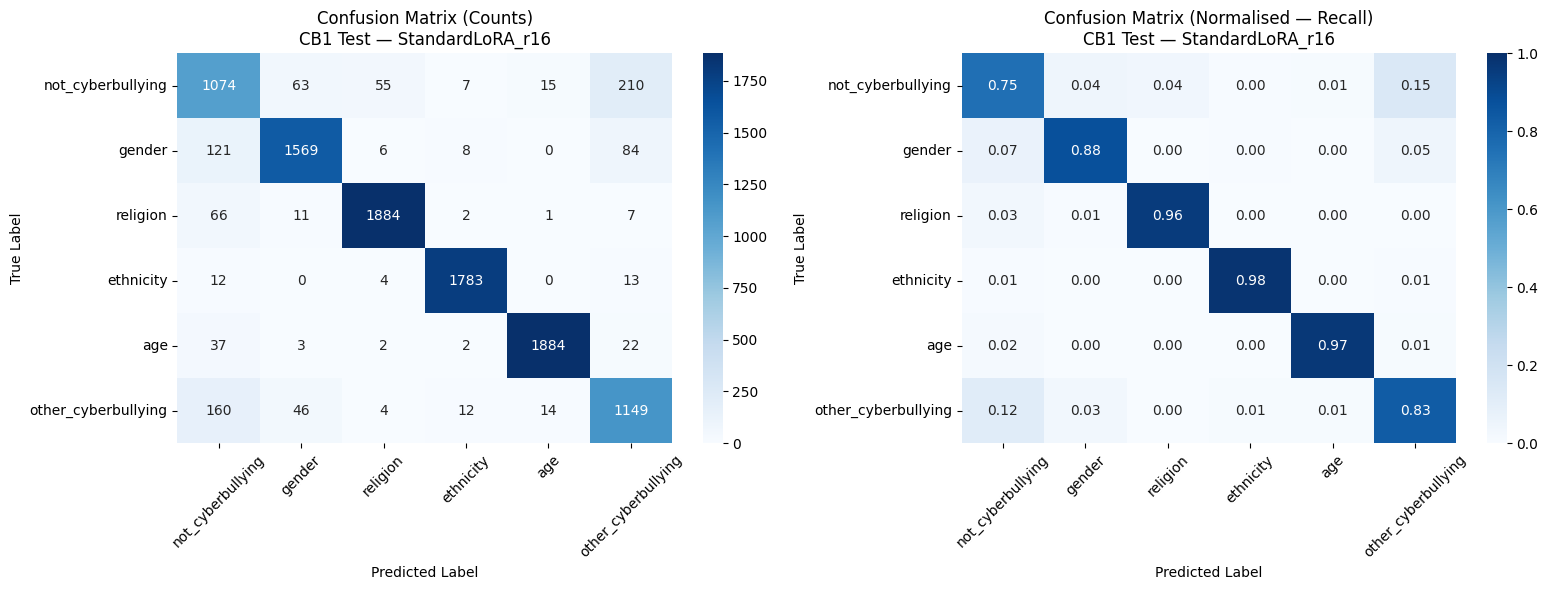


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r16/results_StandardLoRA_r16.csv

════════════════════════════════════════════════════════════
  STAGE 2 RESULTS — Standard LoRA (r=16)
  Formula: Wf = W + AB
  Model  : meta-llama/Llama-3.2-3B-Instruct
════════════════════════════════════════════════════════════
  Macro F1          : 0.8938   ← PRIMARY METRIC
  MCC               : 0.8851
  Accuracy          : 0.9045
  Balanced Accuracy : 0.8946
  Trainable params  : 9,193,472
  Eff. rank Wf      : 2030.73   ← record for Stage 3 comparison
  Eff. rank ΔW      : 16.00   (reference)
  Stability score   : 0.424905   ← lower is better
════════════════════════════════════════════════════════════

  Stage 1 targets:
  CB1 Phi-4 FS Macro F1 = 0.5757  |  MCC = 0.5614  ← beat this
  → Pass results_r16["stability_cb"] to plot_cross_stage_stability() after Stages 3 & 4


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# MAIN EXECUTION — Standard LoRA, default rank r=16
# ════════════════════════════════════════════════════════════════════════════

results_r16 = run_standard_lora(
    train_df  = train_df,
    val_df    = val_df,
    test_df   = test_df,
    lora_rank = 16,
    run_label = 'StandardLoRA_r16'
)

print('\n' + '═'*60)
print('  STAGE 2 RESULTS — Standard LoRA (r=16)')
print('  Formula: Wf = W + AB')
print('  Model  : meta-llama/Llama-3.2-3B-Instruct')
print('═'*60)
print(f'  Macro F1          : {results_r16["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC               : {results_r16["mcc"]:.4f}')
print(f'  Accuracy          : {results_r16["accuracy"]:.4f}')
print(f'  Balanced Accuracy : {results_r16["balanced_accuracy"]:.4f}')
print(f'  Trainable params  : {results_r16["trainable_params"]:,}')
print(f'  Eff. rank Wf      : {results_r16["avg_eff_rank_Wf"]:.2f}   ← record for Stage 3 comparison')
print(f'  Eff. rank ΔW      : {results_r16["avg_eff_rank_dW"]:.2f}   (reference)')
print(f'  Stability score   : {results_r16["stability_score"]}   ← lower is better')
print('═'*60)
print()
print('  Stage 1 targets:')
print('  CB1 Phi-4 FS Macro F1 = 0.5757  |  MCC = 0.5614  ← beat this')
print('  → Pass results_r16["stability_cb"] to plot_cross_stage_stability() after Stages 3 & 4')

---
## Step 13: Rank Sweep Ablation — r ∈ {4, 8, 16, 32}

**Purpose**: Run Standard LoRA for all four ranks to generate the efficiency curve and rank dynamics analysis for the paper.

**Why this matters**: If Stage 2 achieves high F1, the contribution of Stages 3 and 4 becomes an **efficiency story** — Generalised LoRA achieves equal or better accuracy with fewer parameters (lower rank). This sweep provides the data for that argument.

**Output** (4-panel figure):
- Panel 1 — Macro F1 vs rank
- Panel 2 — Efficiency curve (F1 vs trainable parameters)
- Panel 3 — Rank dynamics: eff. rank(Wf) vs eff. rank(ΔW) across r values
- Panel 4 — Stability score vs rank

> **Note**: Each rank requires a full training run (~10–20 min on A100). Run after confirming the r=16 result in Step 12 is correct.


───────────────────────────────────────────────────────
  Rank sweep: r = 4
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r4
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 4  |  Alpha: 4  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

   Trainable: 2,312,192 / 3,215,080,448  (0.072%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.532059,0.469957,0.846410,0.832639,0.815793
400,0.417103,0.433915,0.867010,0.847555,0.841310
600,0.375893,0.375085,0.872463,0.863989,0.847737
800,0.326053,0.351724,0.891548,0.880098,0.869889
1000,0.291827,0.349657,0.890639,0.875691,0.871129
1200,0.365865,0.310929,0.903060,0.892761,0.883459
1400,0.311724,0.294436,0.901242,0.891625,0.881384
1600,0.265304,0.291226,0.902151,0.893208,0.882558
1800,0.256967,0.289566,0.901848,0.892876,0.882232
1857,0.351227,0.289525,0.902151,0.893132,0.882578


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2030.71
   avg_effective_rank(ΔW) = 4.00  (reference, ≤ r=4)
   LoRA layers measured   = 112

[6] Generating stability report...
   Loss CV (overall)   : 0.8586178810451002
   Loss std (overall)  : 0.3735211029809729
   Val F1 std          : 0.020612331359455463
   Val MCC std         : 0.02204301659140828
   Composite score     : 0.439615
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r4/stability_curves.png


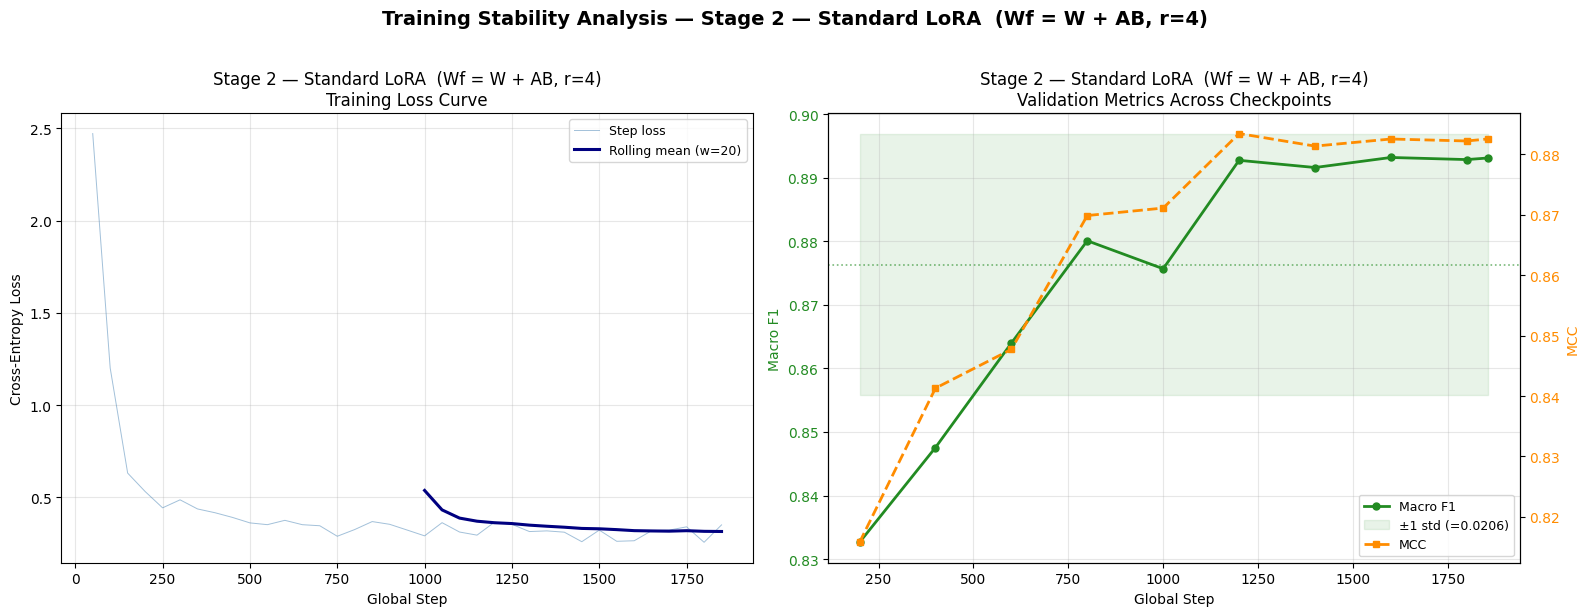

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8991
  Macro F1          : 0.8881  ← PRIMARY METRIC
  Weighted F1       : 0.9002
  Balanced Accuracy : 0.8887
  MCC               : 0.8787  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7136    0.7437    0.7283      1424
             gender     0.9198    0.8725    0.8955      1788
           religion     0.9640    0.9498    0.9568      1971
          ethnicity     0.9774    0.9801    0.9788      1812
                age     0.9833    0.9687    0.9760      1950
other_cyberbullying     0.7701    0.8173    0.7930      1385

           accuracy                         0.8991     10330
          macro avg     0.8880    0.8887    0.8881    

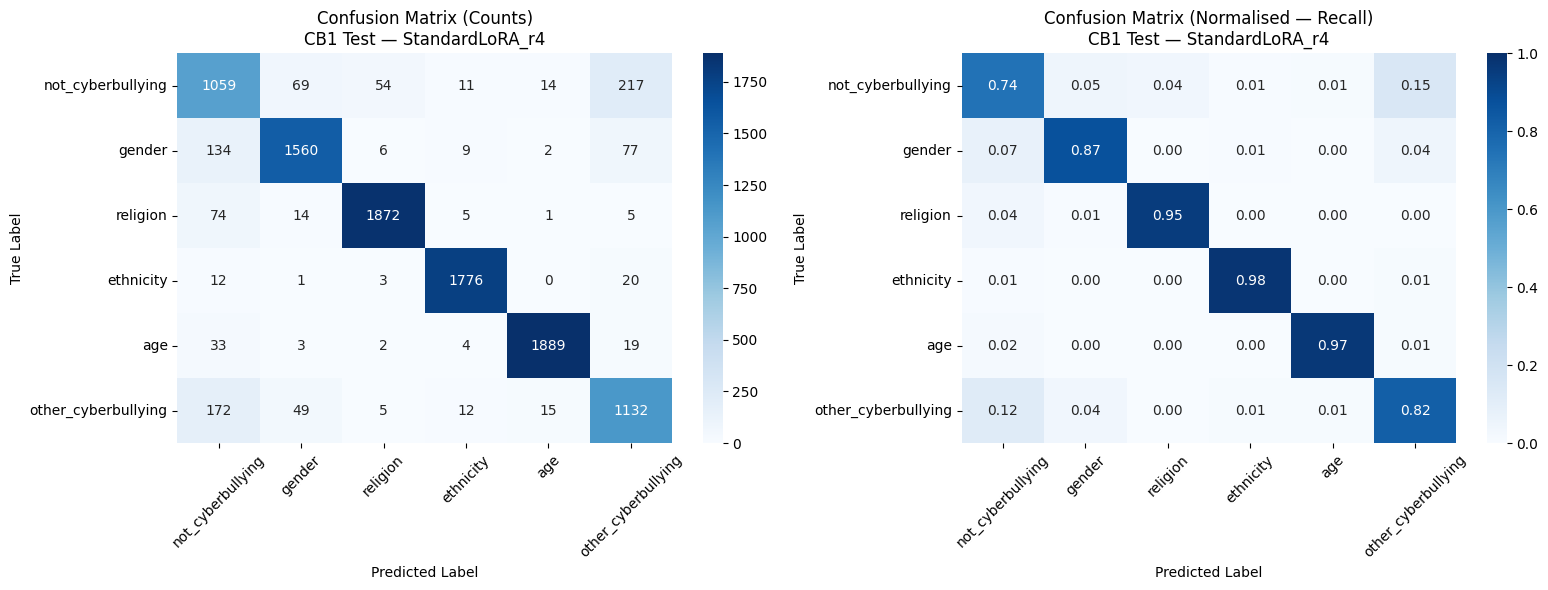


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r4/results_StandardLoRA_r4.csv

───────────────────────────────────────────────────────
  Rank sweep: r = 8
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r8
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 8  |  Alpha: 8  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

   Trainable: 4,605,952 / 3,217,374,208  (0.143%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.511147,0.442851,0.849440,0.835467,0.819724
400,0.417999,0.436636,0.866404,0.845054,0.841487
600,0.383587,0.373024,0.870948,0.861859,0.845980
800,0.325900,0.343834,0.898213,0.887564,0.877784
1000,0.283264,0.347433,0.895183,0.881006,0.876368
1200,0.362244,0.302282,0.909118,0.899811,0.890844
1400,0.307424,0.286009,0.907907,0.898422,0.889364
1600,0.259055,0.282586,0.907907,0.899223,0.889445
1800,0.251070,0.280574,0.908210,0.899733,0.889846
1857,0.346570,0.280445,0.907907,0.899324,0.889473


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2030.72
   avg_effective_rank(ΔW) = 8.00  (reference, ≤ r=8)
   LoRA layers measured   = 112

[6] Generating stability report...
   Loss CV (overall)   : 0.8418531350268719
   Loss std (overall)  : 0.35783729942808307
   Val F1 std          : 0.023346063524068563
   Val MCC std         : 0.02443096002377016
   Composite score     : 0.4326
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r8/stability_curves.png


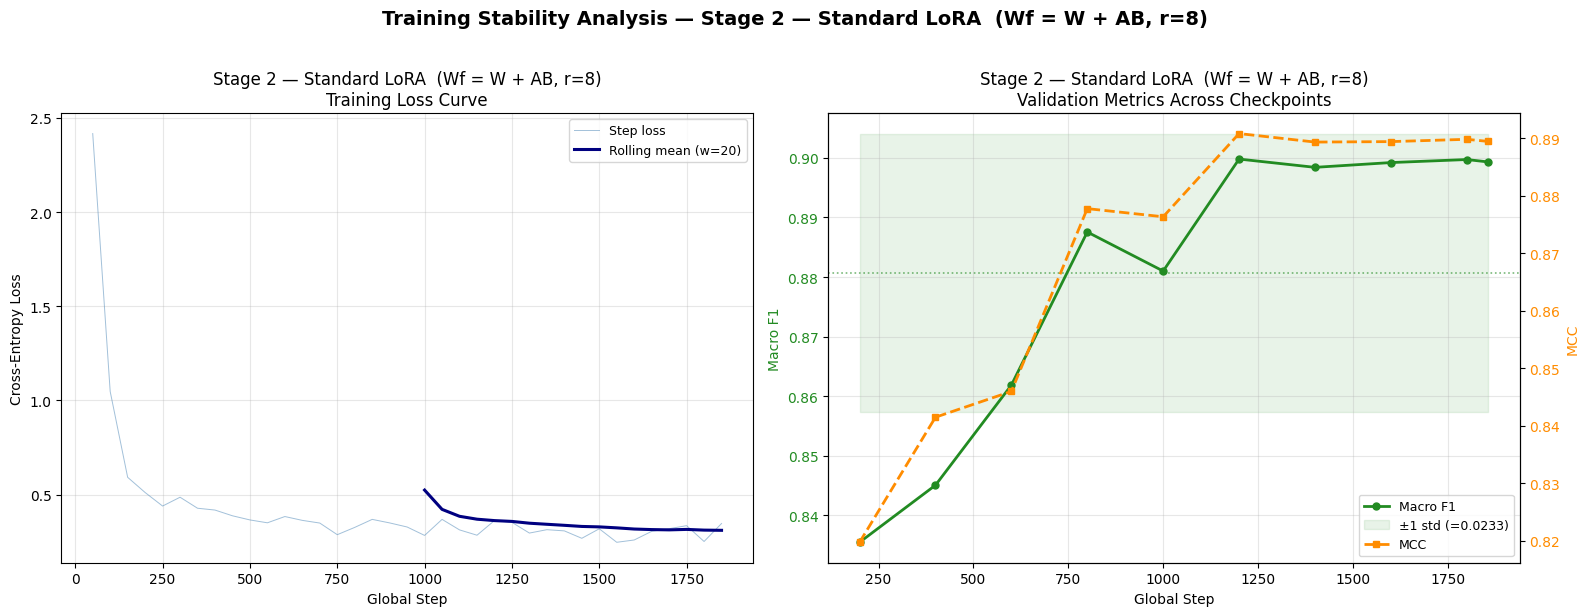

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9012
  Macro F1          : 0.8902  ← PRIMARY METRIC
  Weighted F1       : 0.9021
  Balanced Accuracy : 0.8908
  MCC               : 0.8811  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7194    0.7437    0.7314      1424
             gender     0.9215    0.8736    0.8969      1788
           religion     0.9626    0.9538    0.9582      1971
          ethnicity     0.9807    0.9834    0.9821      1812
                age     0.9828    0.9672    0.9749      1950
other_cyberbullying     0.7734    0.8231    0.7975      1385

           accuracy                         0.9012     10330
          macro avg     0.8901    0.8908    0.8902    

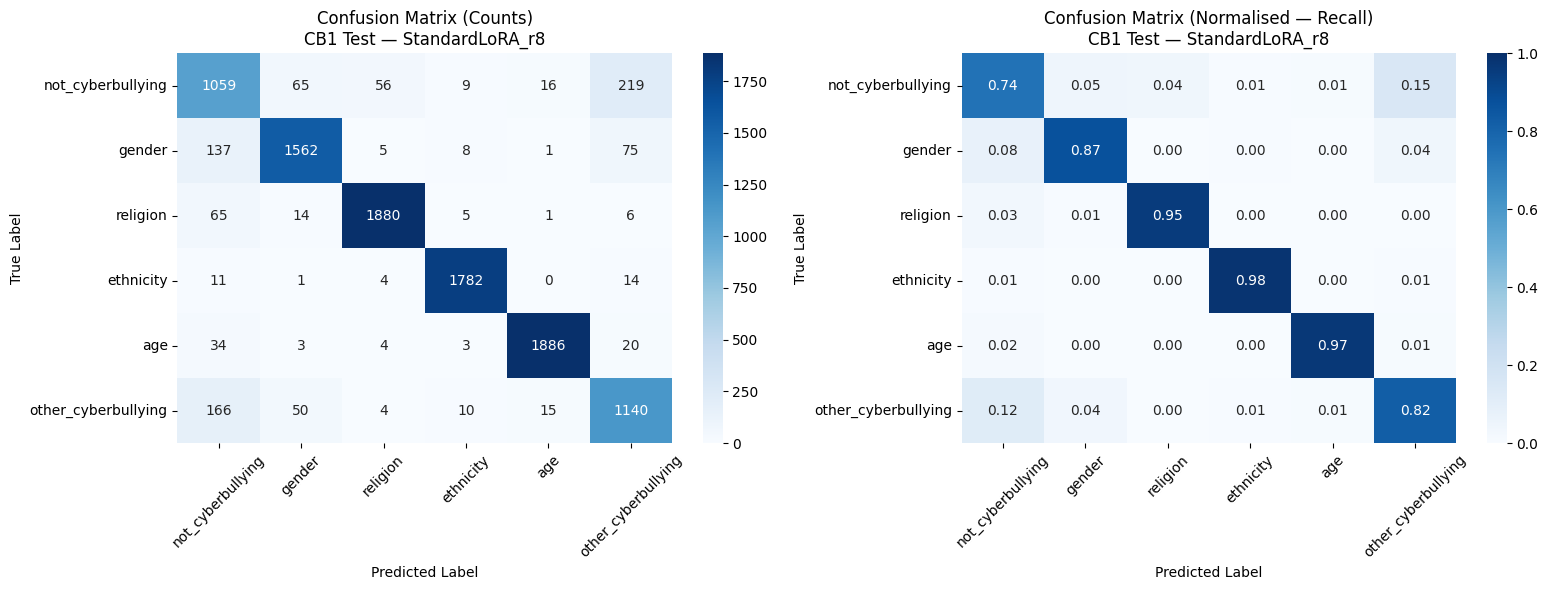


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r8/results_StandardLoRA_r8.csv

───────────────────────────────────────────────────────
  Rank sweep: r = 16
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r16
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

   Trainable: 9,193,472 / 3,221,961,728  (0.285%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.509117,0.443890,0.847622,0.830707,0.818979
400,0.415798,0.451480,0.869736,0.848490,0.845233
600,0.380967,0.372116,0.878825,0.870053,0.855677
800,0.338911,0.350250,0.900636,0.889653,0.880750
1000,0.286124,0.366660,0.888216,0.872032,0.869209
1200,0.359507,0.289259,0.912754,0.903418,0.895091
1400,0.303935,0.280552,0.909724,0.900424,0.891629
1600,0.254335,0.276471,0.910330,0.901695,0.892307
1800,0.233726,0.273205,0.911239,0.902876,0.893423
1857,0.351219,0.272966,0.911239,0.902871,0.893418


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2030.73
   avg_effective_rank(ΔW) = 16.00  (reference, ≤ r=16)
   LoRA layers measured   = 112

[6] Generating stability report...
   Loss CV (overall)   : 0.8250890329112768
   Loss std (overall)  : 0.34319385762043336
   Val F1 std          : 0.024721563075468946
   Val MCC std         : 0.024702983008093447
   Composite score     : 0.424905
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r16/stability_curves.png


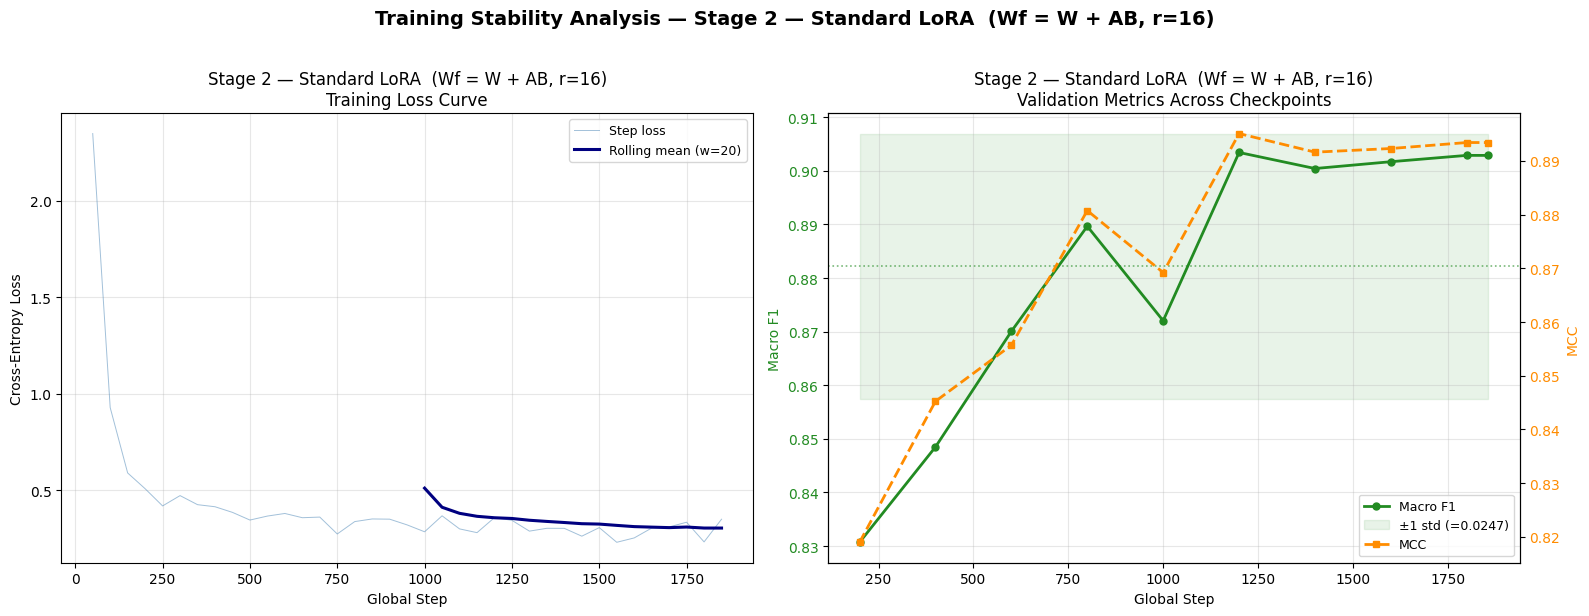

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9045
  Macro F1          : 0.8938  ← PRIMARY METRIC
  Weighted F1       : 0.9055
  Balanced Accuracy : 0.8946
  MCC               : 0.8851  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7306    0.7542    0.7422      1424
             gender     0.9273    0.8775    0.9017      1788
           religion     0.9637    0.9559    0.9598      1971
          ethnicity     0.9829    0.9840    0.9835      1812
                age     0.9843    0.9662    0.9752      1950
other_cyberbullying     0.7737    0.8296    0.8007      1385

           accuracy                         0.9045     10330
          macro avg     0.8938    0.8946    0.8938   

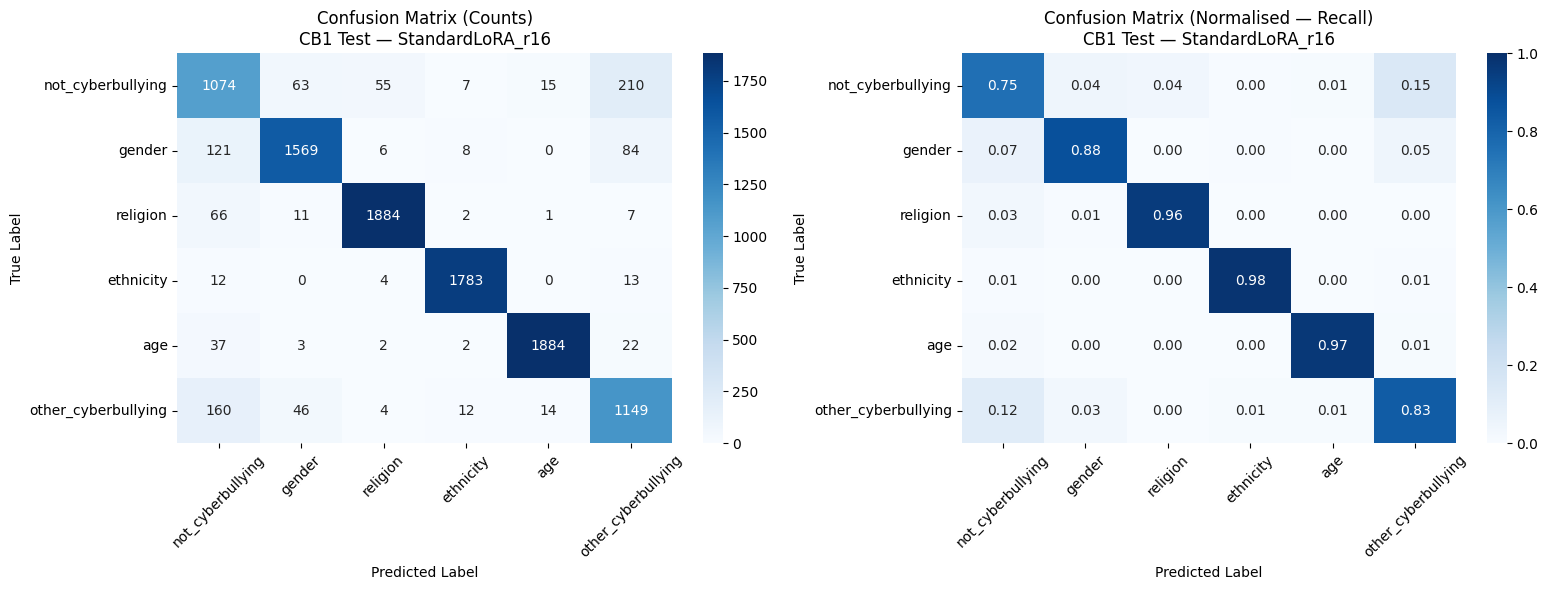


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r16/results_StandardLoRA_r16.csv

───────────────────────────────────────────────────────
  Rank sweep: r = 32
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r32
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

   Trainable: 18,368,512 / 3,231,136,768  (0.568%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.513861,0.475809,0.817934,0.796272,0.791288
400,0.429983,0.495455,0.860345,0.834178,0.835412
600,0.371799,0.367806,0.878219,0.868074,0.855104
800,0.327891,0.340189,0.897607,0.887413,0.877498
1000,0.279448,0.383504,0.883066,0.863659,0.864289
1200,0.341817,0.286176,0.912148,0.902087,0.894405
1400,0.294127,0.273258,0.914268,0.905778,0.897079
1600,0.237828,0.270696,0.914571,0.906507,0.897436
1800,0.230432,0.265994,0.913965,0.905817,0.896719
1857,0.344560,0.265859,0.913360,0.905200,0.895990


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2030.76
   avg_effective_rank(ΔW) = 32.00  (reference, ≤ r=32)
   LoRA layers measured   = 112

[6] Generating stability report...
   Loss CV (overall)   : 0.8019307111963963
   Loss std (overall)  : 0.32488656169100016
   Val F1 std          : 0.03559246595887225
   Val MCC std         : 0.03342283406468382
   Composite score     : 0.418762
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r32/stability_curves.png


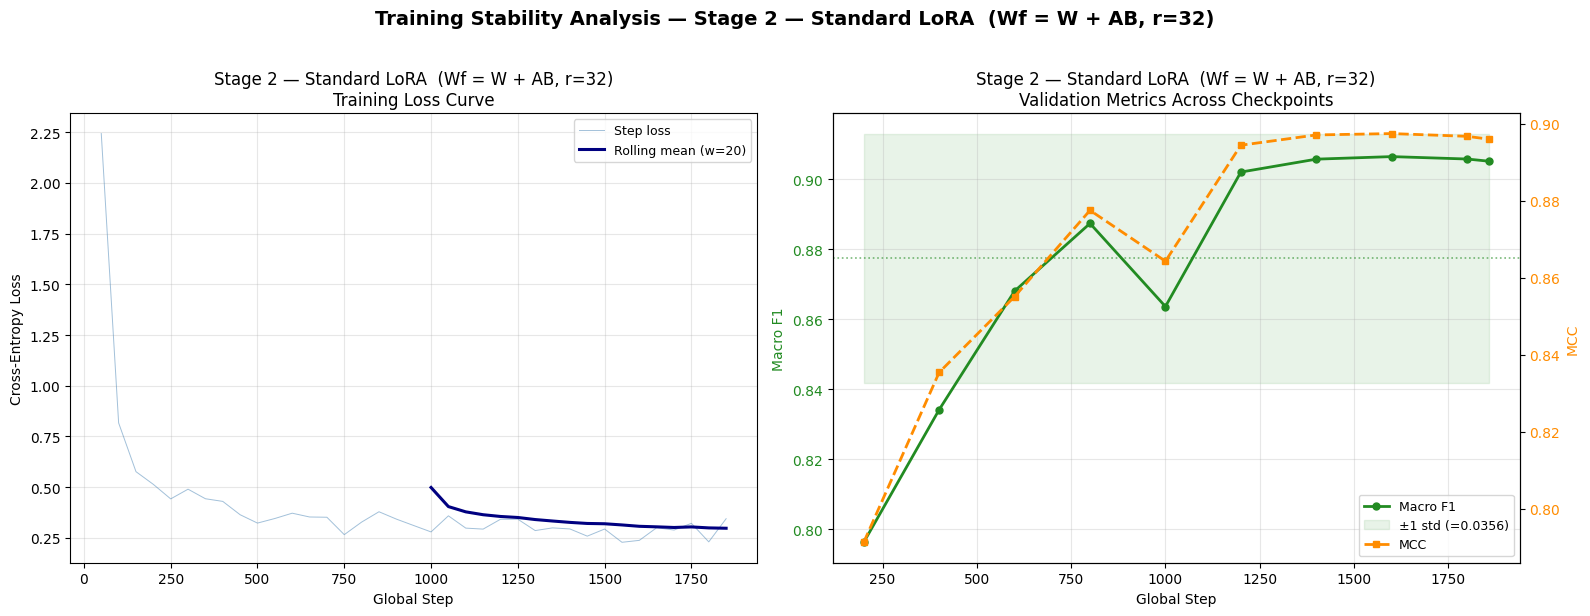

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9064
  Macro F1          : 0.8958  ← PRIMARY METRIC
  Weighted F1       : 0.9073
  Balanced Accuracy : 0.8962
  MCC               : 0.8874  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7273    0.7662    0.7462      1424
             gender     0.9185    0.8826    0.9002      1788
           religion     0.9662    0.9579    0.9620      1971
          ethnicity     0.9862    0.9862    0.9862      1812
                age     0.9854    0.9692    0.9772      1950
other_cyberbullying     0.7906    0.8152    0.8027      1385

           accuracy                         0.9064     10330
          macro avg     0.8957    0.8962    0.8958   

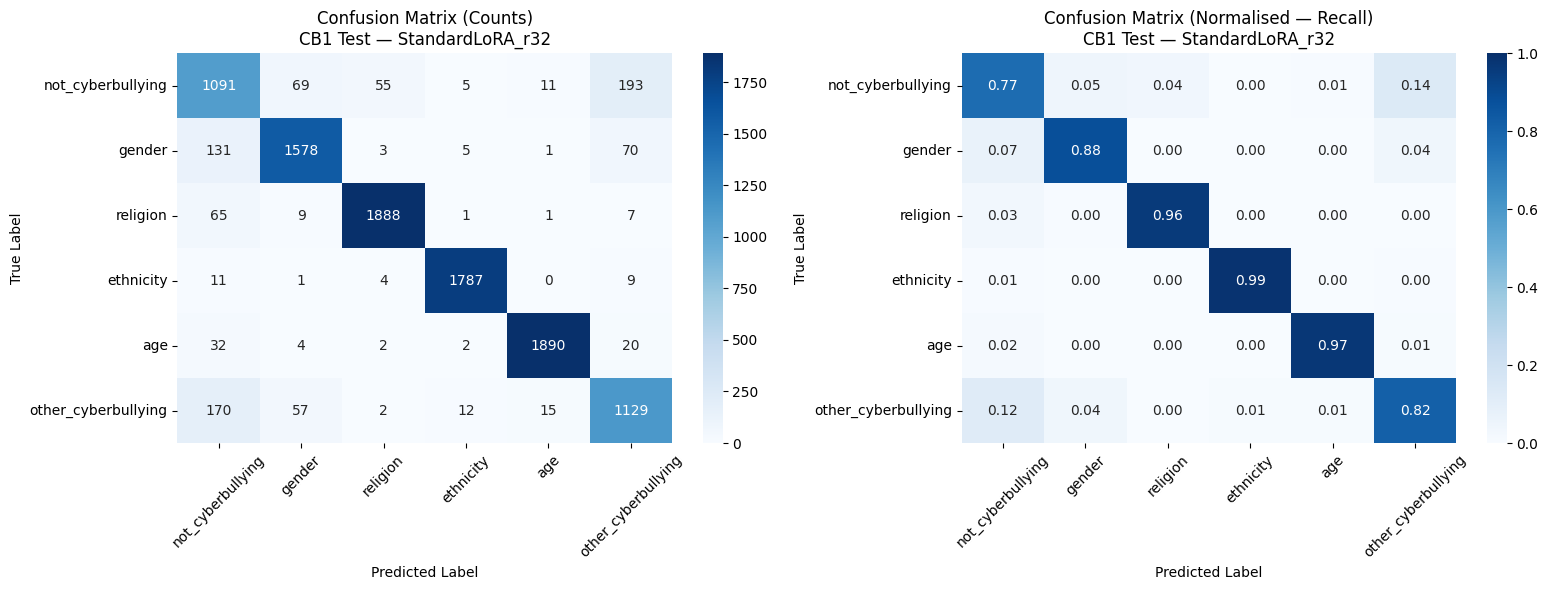


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/StandardLoRA_r32/results_StandardLoRA_r32.csv

═════════════════════════════════════════════════════════════════════════════════════
RANK SWEEP RESULTS — Stage 2 Standard LoRA
═════════════════════════════════════════════════════════════════════════════════════
 Rank (r)  Trainable Params  Macro F1    MCC  Accuracy  Eff. Rank (Wf)  Eff. Rank (ΔW)  Stability Score
        4           2312192    0.8881 0.8787    0.8991         2030.71             4.0         0.439615
        8           4605952    0.8902 0.8811    0.9012         2030.72             8.0         0.432600
       16           9193472    0.8938 0.8851    0.9045         2030.73            16.0         0.424905
       32          18368512    0.8958 0.8874    0.9064         2030.76            32.0         0.418762

✓ Summary saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Llama3B/rank_sweep_summary.csv


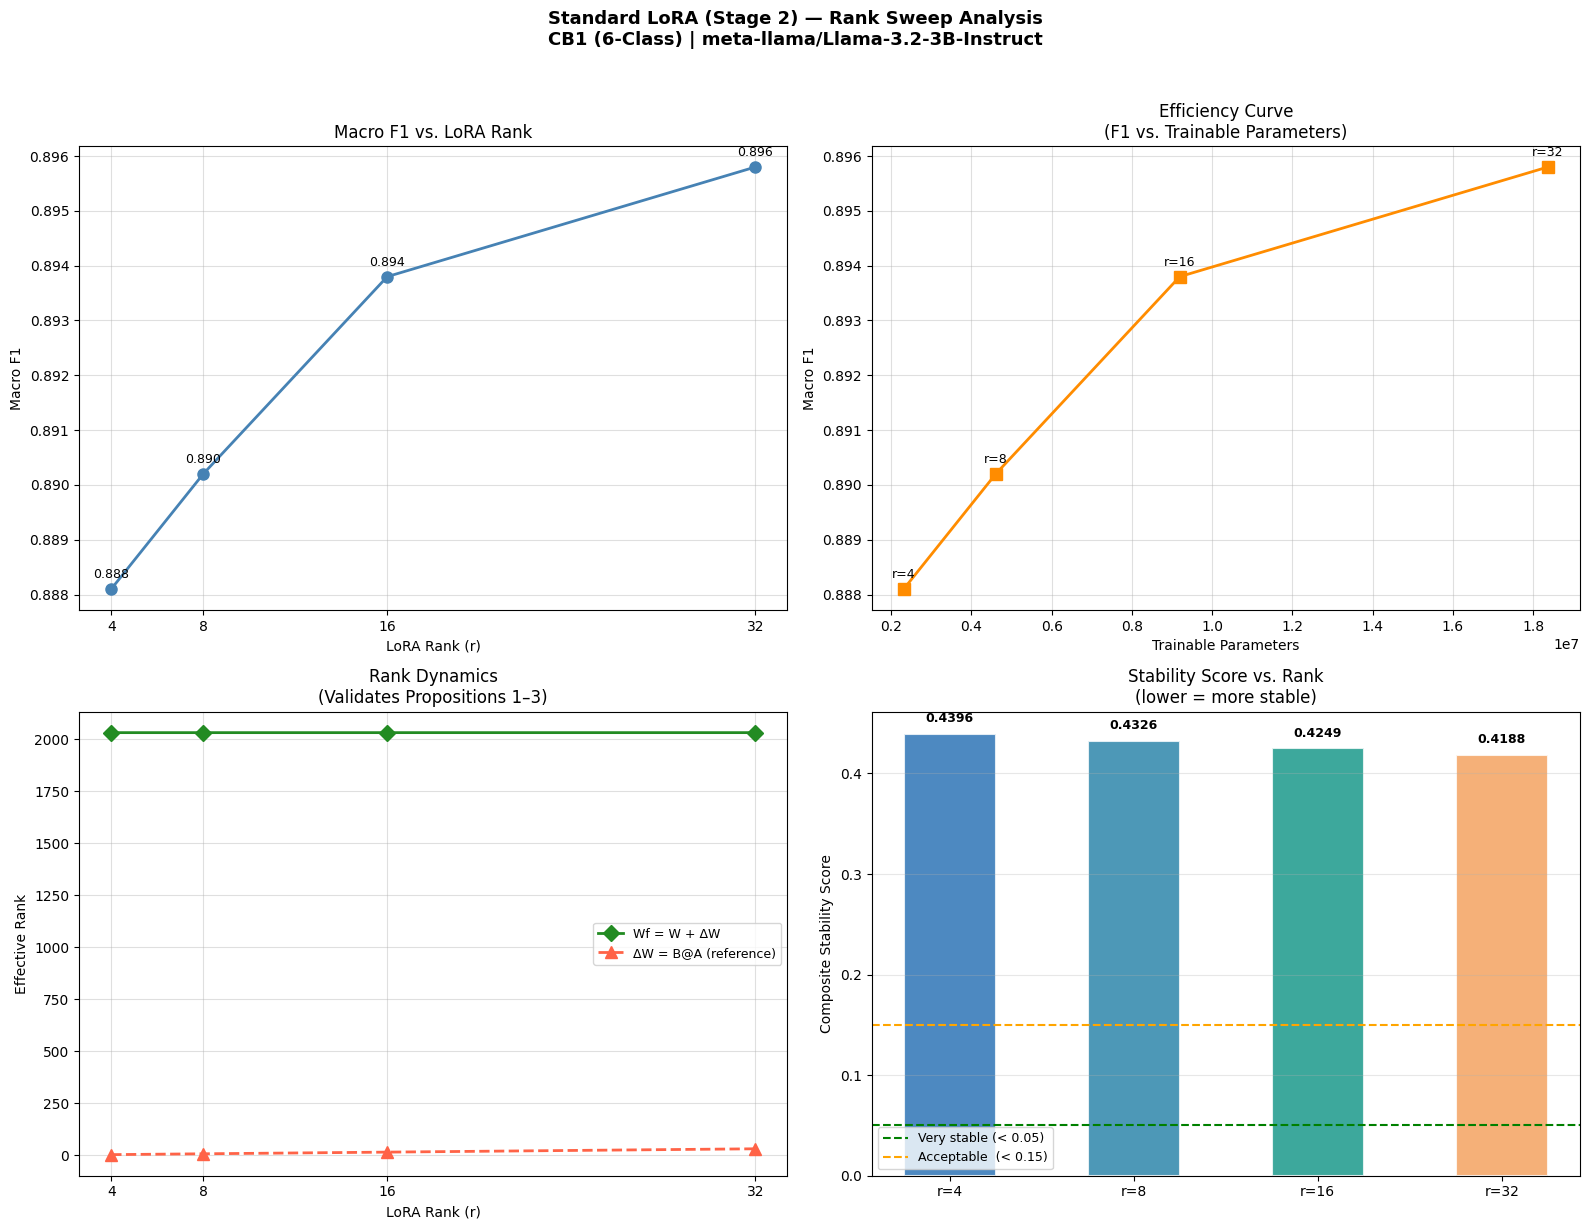

✓ Rank sweep plots saved.


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# RANK SWEEP: r ∈ {4, 8, 16, 32}
# Run AFTER confirming the r=16 result in Step 12 is correct
# ════════════════════════════════════════════════════════════════════════════

all_rank_results = []

for r in RANK_SWEEP:
    print(f'\n{"─"*55}')
    print(f'  Rank sweep: r = {r}')
    print(f'{"─"*55}')
    res = run_standard_lora(
        train_df  = train_df,
        val_df    = val_df,
        test_df   = test_df,
        lora_rank = r,
        run_label = f'StandardLoRA_r{r}'
    )
    all_rank_results.append(res)

# ── Summary table ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame([{
    'Rank (r)':         res['lora_rank'],
    'Trainable Params': res['trainable_params'],
    'Macro F1':         round(res['macro_f1'],          4),
    'MCC':              round(res['mcc'],                4),
    'Accuracy':         round(res['accuracy'],           4),
    'Eff. Rank (Wf)':   round(res['avg_eff_rank_Wf'],   2),
    'Eff. Rank (ΔW)':   round(res['avg_eff_rank_dW'],   2),
    'Stability Score':  round(res['stability_score'],   6),
} for res in all_rank_results])

print('\n' + '═'*85)
print('RANK SWEEP RESULTS — Stage 2 Standard LoRA')
print('═'*85)
print(summary_df.to_string(index=False))

summary_path = os.path.join(OUTPUT_DIR, 'rank_sweep_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f'\n✓ Summary saved → {summary_path}')

# ── 4-panel rank sweep figure ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].plot(summary_df['Rank (r)'], summary_df['Macro F1'],
               'o-', color='steelblue', linewidth=2, markersize=8)
for _, row in summary_df.iterrows():
    axes[0,0].annotate(f'{row["Macro F1"]:.3f}',
                       (row['Rank (r)'], row['Macro F1']),
                       textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
axes[0,0].set_title('Macro F1 vs. LoRA Rank', fontsize=12)
axes[0,0].set_xlabel('LoRA Rank (r)')
axes[0,0].set_ylabel('Macro F1')
axes[0,0].set_xticks(RANK_SWEEP)
axes[0,0].grid(True, alpha=0.4)

axes[0,1].plot(summary_df['Trainable Params'], summary_df['Macro F1'],
               's-', color='darkorange', linewidth=2, markersize=8)
for _, row in summary_df.iterrows():
    axes[0,1].annotate(f'r={int(row["Rank (r)"])}',
                       (row['Trainable Params'], row['Macro F1']),
                       textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
axes[0,1].set_title('Efficiency Curve\n(F1 vs. Trainable Parameters)', fontsize=12)
axes[0,1].set_xlabel('Trainable Parameters')
axes[0,1].set_ylabel('Macro F1')
axes[0,1].grid(True, alpha=0.4)

axes[1,0].plot(summary_df['Rank (r)'], summary_df['Eff. Rank (Wf)'],
               'D-', color='forestgreen', linewidth=2, markersize=8, label='Wf = W + ΔW')
axes[1,0].plot(summary_df['Rank (r)'], summary_df['Eff. Rank (ΔW)'],
               '^--', color='tomato', linewidth=2, markersize=8, label='ΔW = B@A (reference)')
axes[1,0].set_title('Rank Dynamics\n(Validates Propositions 1–3)', fontsize=12)
axes[1,0].set_xlabel('LoRA Rank (r)')
axes[1,0].set_ylabel('Effective Rank')
axes[1,0].set_xticks(RANK_SWEEP)
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.4)

axes[1,1].bar(range(len(RANK_SWEEP)), summary_df['Stability Score'],
              color=['#2E75B6','#2E86AB','#1B998B','#F4A261'],
              alpha=0.85, edgecolor='white', linewidth=1.5, width=0.5)
for i, (_, row) in enumerate(summary_df.iterrows()):
    axes[1,1].text(i, row['Stability Score'] + max(summary_df['Stability Score'])*0.02,
                   f'{row["Stability Score"]:.4f}', ha='center', va='bottom',
                   fontsize=9, fontweight='bold')
axes[1,1].axhline(0.05,  color='green',  linestyle='--', linewidth=1.5, label='Very stable (< 0.05)')
axes[1,1].axhline(0.15,  color='orange', linestyle='--', linewidth=1.5, label='Acceptable  (< 0.15)')
axes[1,1].set_xticks(range(len(RANK_SWEEP)))
axes[1,1].set_xticklabels([f'r={r}' for r in RANK_SWEEP], fontsize=10)
axes[1,1].set_title('Stability Score vs. Rank\n(lower = more stable)', fontsize=12)
axes[1,1].set_ylabel('Composite Stability Score')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'Standard LoRA (Stage 2) — Rank Sweep Analysis\n'
    'CB1 (6-Class) | meta-llama/Llama-3.2-3B-Instruct',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rank_sweep_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Rank sweep plots saved.')

---
## Step 14: Cross-Stage Stability Comparison (Run After All Stages Complete)

**Purpose**: Compare training stability across Stages 2, 3, and 4 in a single publication-ready figure.

**When to run**: After Stage 3 (Multiplicative LoRA) and Stage 4 (Generalised LoRA) notebooks have completed.

**Figure shows** (4 side-by-side bar charts):
1. Loss Std Dev (overall)
2. Loss CV (Coefficient of Variation)
3. Val F1 Std Dev across checkpoints
4. Composite Stability Score with colour-coded zones

**Paper use**: Supports the claim that Generalised LoRA maintains or improves training stability over the additive-only baseline.

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 14A: CROSS-STAGE STABILITY COMPARISON
# Uncomment after Stage 3 and Stage 4 notebooks complete
# ════════════════════════════════════════════════════════════════════════════

# --- TEMPLATE: fill in results_s3 and results_s4 after those stages ---
# plot_cross_stage_stability(
#     stage_reports={
#         'Stage 2\nWf = W + AB':        results_r16['stability_cb'].get_stability_report(),
#         'Stage 3\nWf = W(I+UV)':       results_s3['stability_cb'].get_stability_report(),
#         'Stage 4\nWf = W(I+UV)+AB':    results_s4['stability_cb'].get_stability_report(),
#     },
#     save_path=os.path.join(OUTPUT_DIR, 'cross_stage_stability.png')
# )

# ── Stage 2 only — available now ─────────────────────────────────────────────
print('Stage 2 stability report (r=16):')
rep = results_r16['stability_cb'].get_stability_report()
print(f'  loss_cv_overall  : {rep.get("loss_cv_overall",  "N/A")}')
print(f'  loss_std_overall : {rep.get("loss_std_overall", "N/A")}')
print(f'  val_f1_std       : {rep.get("val_f1_std",       "N/A")}')
print(f'  val_mcc_std      : {rep.get("val_mcc_std",      "N/A")}')
print(f'  stability_score  : {rep.get("stability_score",  "N/A")}')

# ════════════════════════════════════════════════════════════════════════════
# STEP 14B: FINAL STAGE 2 SUMMARY — for paper results tables
# ════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  STAGE 2 COMPLETE — STANDARD (ADDITIVE) LoRA')
print('  Formula  : Wf = W + AB')
print('  Model    : meta-llama/Llama-3.2-3B-Instruct')
print('  Dataset  : CB1 — 6-Class Cyberbullying Detection')
print('  Split    : 75/25 stratified (protocol-compliant)')
print('═'*70)

print('\n── PRIMARY RESULTS (r=16) ──')
print(f'  Macro F1           : {results_r16["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC                : {results_r16["mcc"]:.4f}')
print(f'  Accuracy           : {results_r16["accuracy"]:.4f}')
print(f'  Balanced Accuracy  : {results_r16["balanced_accuracy"]:.4f}')
print(f'  Trainable params   : {results_r16["trainable_params"]:,}')
print(f'  Eff. rank (Wf)     : {results_r16["avg_eff_rank_Wf"]:.2f}  ← compare to Stages 3 & 4')
print(f'  Stability score    : {results_r16["stability_score"]}')

print('\n── ALL FIXES APPLIED ──')
print('  [✓] Bug 1: effective_rank measures Wf = W + ΔW (not ΔW alone)')
print('  [✓] Bug 2: 6-class label mapping (gender, ethnicity)')
print(f'  [✓] Bug 3: lora_alpha = lora_rank  →  scaling = 1.0')
print('  [✓] Bug 4: EarlyStoppingCallback removed (meaningless, 1 epoch)')
print('  [✓] R4   : 75/25 split — test set is full 25% held-out')
print('  [✓] R5   : Stability plot is 2-panel (no grad norm / per-epoch panels)')

Stage 2 stability report (r=16):
  loss_cv_overall  : 0.8250890329112768
  loss_std_overall : 0.34319385762043336
  val_f1_std       : 0.024721563075468946
  val_mcc_std      : 0.024702983008093447
  stability_score  : 0.424905

══════════════════════════════════════════════════════════════════════
  STAGE 2 COMPLETE — STANDARD (ADDITIVE) LoRA
  Formula  : Wf = W + AB
  Model    : meta-llama/Llama-3.2-3B-Instruct
  Dataset  : CB1 — 6-Class Cyberbullying Detection
  Split    : 75/25 stratified (protocol-compliant)
══════════════════════════════════════════════════════════════════════

── PRIMARY RESULTS (r=16) ──
  Macro F1           : 0.8938   ← PRIMARY METRIC
  MCC                : 0.8851
  Accuracy           : 0.9045
  Balanced Accuracy  : 0.8946
  Trainable params   : 9,193,472
  Eff. rank (Wf)     : 2030.73  ← compare to Stages 3 & 4
  Stability score    : 0.424905

── ALL FIXES APPLIED ──
  [✓] Bug 1: effective_rank measures Wf = W + ΔW (not ΔW alone)
  [✓] Bug 2: 6-class label ma